In [1]:
import pandas as pd
from pymongo import MongoClient
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Conexión a MongoDB y Extracción
cliente_mongo = MongoClient('mongodb://localhost:27017/')
db = cliente_mongo['taller4_db']
coleccion = db['raw_data']

# Traemos todos los documentos de la colección
datos_crudos = list(coleccion.find())

# 2. Creación del DataFrame y Selección de Variables (5 columnas clave)
df_completo = pd.DataFrame(datos_crudos)

# Seleccionamos las 5 variables exigidas por la rúbrica
columnas_seleccionadas = ['title', 'artist_display', 'date_display', 'department_title', 'place_of_origin']
df = df_completo[columnas_seleccionadas].copy()

# 3. Limpieza Básica (Manejo de Nulos)
# Rellenamos los valores nulos con 'Desconocido' para no perder las obras en el análisis
df.fillna('Desconocido', inplace=True)

# 4. Inspección Básica (Exigencia de la rúbrica)
print("--- Información del DataFrame ---")
df.info()
print("\n--- Primeras 5 filas ---")
display(df.head())

Matplotlib is building the font cache; this may take a moment.


--- Información del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   title             150 non-null    str  
 1   artist_display    150 non-null    str  
 2   date_display      150 non-null    str  
 3   department_title  150 non-null    str  
 4   place_of_origin   150 non-null    str  
dtypes: str(5)
memory usage: 6.0 KB

--- Primeras 5 filas ---


,title,artist_display,date_display,department_title,place_of_origin
0,Arbor Day,"Eugene Francis Savage (American, 1883–1966)",1920,Arts of the Americas,United States
1,Linear,"Designed by Joseph R. Bobrowicz (American, bor...",1950s,Textiles,Pennsylvania
2,3-D Squares,"Bobbi Shortlidge (American, born 1944)\nUnited...",1989,Textiles,Illinois
3,Peacock Weather Vane,"Artist unknown (American, active 19th century)...",1800–60,Arts of the Americas,Pennsylvania
4,Panel (Upholstery Fabric),"Yvonne Palmer Pacanovsky Bobrowicz (American, ...",1951,Textiles,Pennsylvania


In [2]:
print("--- 5 INSIGHTS NUMÉRICOS RELEVANTES ---")

# Insight 1: Departamentos más activos
top_departamento = df['department_title'].value_counts().idxmax()
conteo_top_dep = df['department_title'].value_counts().max()
print(f"1. El departamento con más obras en esta muestra es '{top_departamento}' con {conteo_top_dep} obras.")

# Insight 2: Origen de las obras
top_origen = df['place_of_origin'].value_counts().idxmax()
conteo_top_origen = df['place_of_origin'].value_counts().max()
print(f"2. El lugar de origen más frecuente de las obras es '{top_origen}' con {conteo_top_origen} obras.")

# Insight 3: Diversidad de Orígenes
origenes_unicos = df['place_of_origin'].nunique()
print(f"3. La colección analizada proviene de {origenes_unicos} lugares de origen distintos en el mundo.")

# Insight 4: Obras sin departamento asignado
obras_sin_dep = len(df[df['department_title'] == 'Desconocido'])
print(f"4. Hay {obras_sin_dep} obras que actualmente no tienen un departamento asignado en el museo.")

# Insight 5: Diversidad de Artistas
artistas_unicos = df['artist_display'].nunique()
print(f"5. Las 150 obras fueron creadas por {artistas_unicos} artistas o entidades distintas.")

--- 5 INSIGHTS NUMÉRICOS RELEVANTES ---
1. El departamento con más obras en esta muestra es 'AIC Archives' con 59 obras.
2. El lugar de origen más frecuente de las obras es 'Desconocido' con 60 obras.
3. La colección analizada proviene de 41 lugares de origen distintos en el mundo.
4. Hay 1 obras que actualmente no tienen un departamento asignado en el museo.
5. Las 150 obras fueron creadas por 120 artistas o entidades distintas.


/var/folders/l_/x1ltlck17h55cg1x4d28hrf80000gn/T/ipykernel_1724/903668771.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_origenes.values, y=top_10_origenes.index, palette="viridis")
/var/folders/l_/x1ltlck17h55cg1x4d28hrf80000gn/T/ipykernel_1724/903668771.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='autor_conocido', palette="Set2")


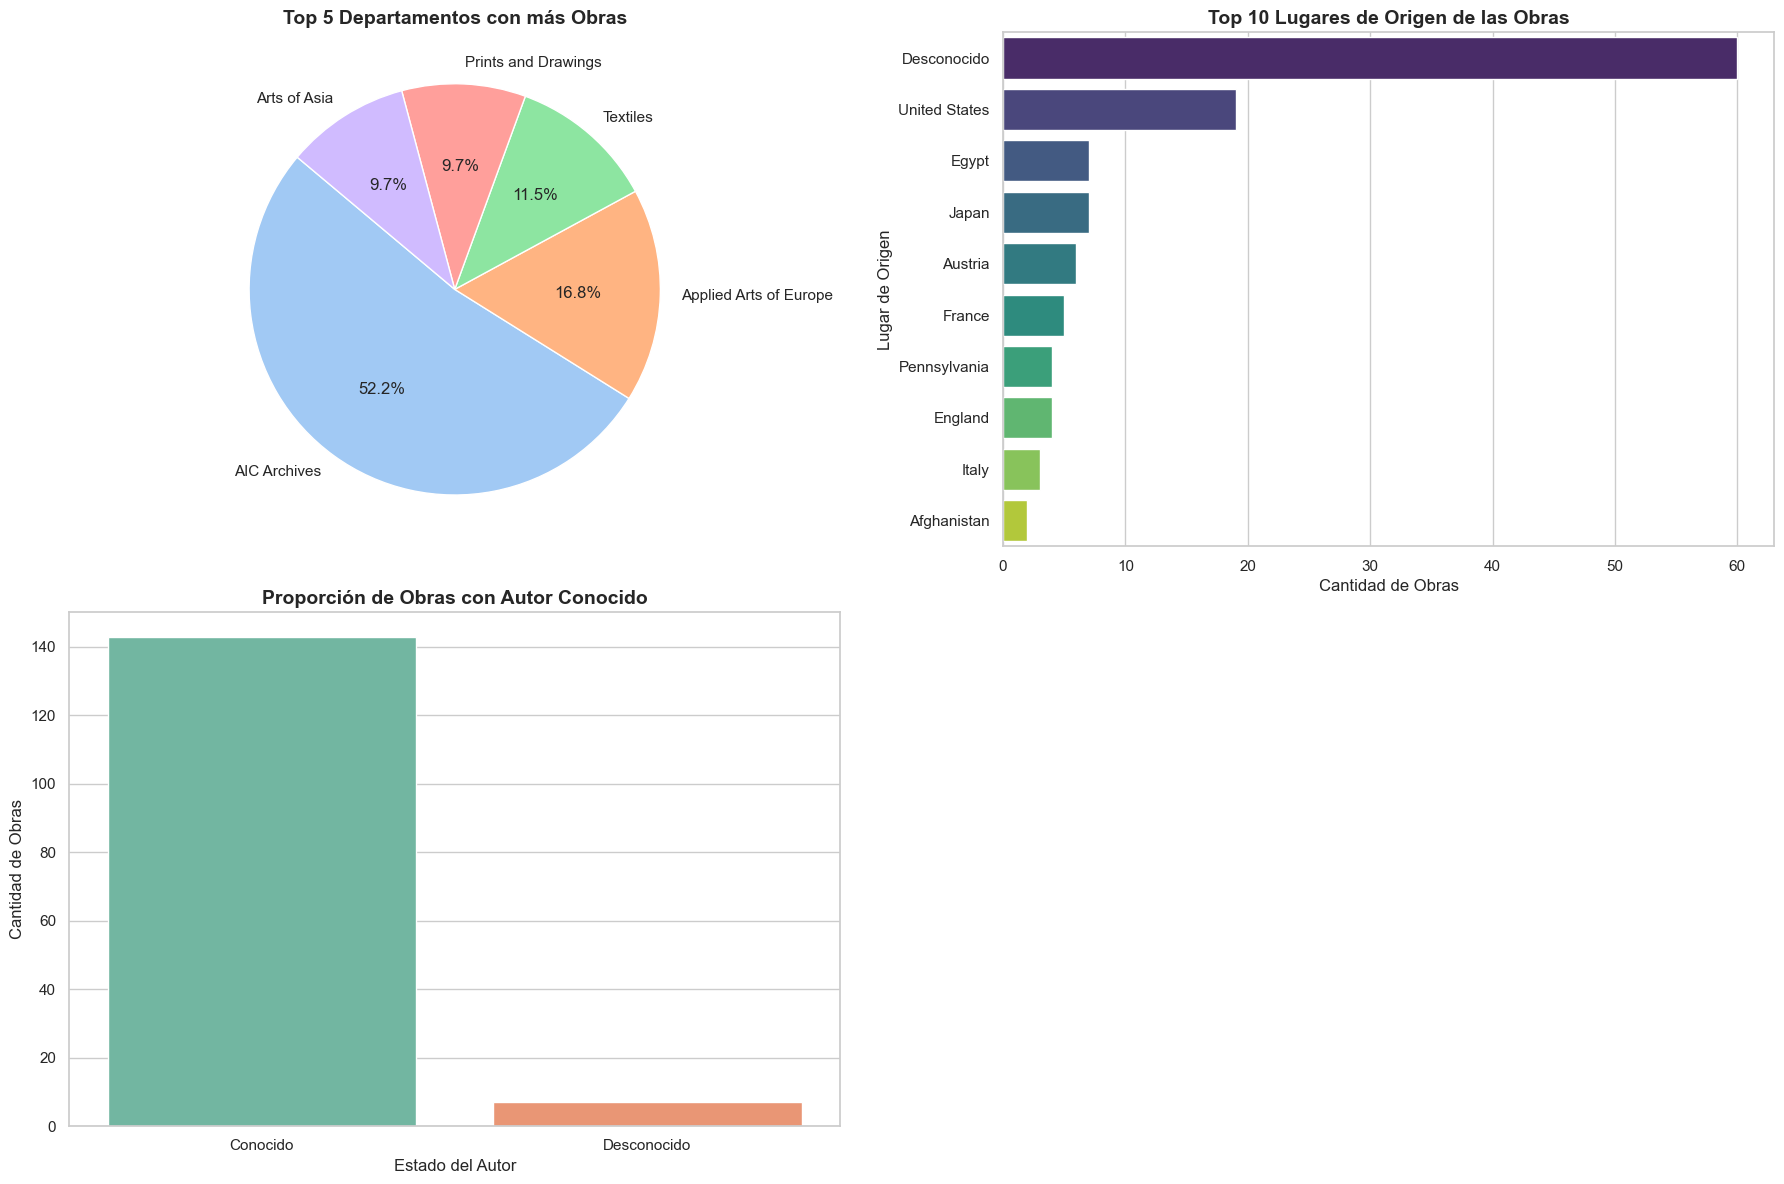

In [3]:
# Configuración general de estilo para las gráficas
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12))

# --- Gráfico 1: Gráfico de Torta (Obligatorio) ---
# Proporción de obras por Departamento (Top 5 para que sea legible)
plt.subplot(2, 2, 1)
top_5_deps = df['department_title'].value_counts().head(5)
plt.pie(top_5_deps.values, labels=top_5_deps.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Top 5 Departamentos con más Obras', fontsize=14, fontweight='bold')

# --- Gráfico 2: Gráfico de Barras (Libre 1) ---
# Top 10 Lugares de Origen
plt.subplot(2, 2, 2)
top_10_origenes = df['place_of_origin'].value_counts().head(10)
sns.barplot(x=top_10_origenes.values, y=top_10_origenes.index, palette="viridis")
plt.title('Top 10 Lugares de Origen de las Obras', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Obras')
plt.ylabel('Lugar de Origen')

# --- Gráfico 3: Histograma / Conteo (Libre 2) ---
# Obras con autor conocido vs desconocido
plt.subplot(2, 2, 3)
# Creamos una columna temporal para saber si el autor es conocido
df['autor_conocido'] = df['artist_display'].apply(lambda x: 'Desconocido' if x == 'Desconocido' else 'Conocido')
sns.countplot(data=df, x='autor_conocido', palette="Set2")
plt.title('Proporción de Obras con Autor Conocido', fontsize=14, fontweight='bold')
plt.xlabel('Estado del Autor')
plt.ylabel('Cantidad de Obras')

# Ajustamos el diseño para que no se superpongan
plt.tight_layout()
plt.show()
